In [4]:
import pandas as pd

df_2020 = pd.read_csv(
    "data/parking_2020.csv",
    encoding="utf-8"
)

df_hotspot = pd.read_csv(
    "data/parking_hotspot_2021.csv",
    encoding="utf-8"
)

df_2024 = pd.read_csv(
    "data/parking_violation_2024.csv",
    encoding="cp949"
)

df_2026 = pd.read_csv(
    "data/parking_violation_2026.csv",
    encoding="utf-8"
)

In [3]:
import pandas as pd

df = pd.read_csv(
    "data/parking_violation_2024.csv",
    encoding="cp949"
)

df.head()

,구분,위반일자,위반시간,위반장소,과태료부과일자,데이터기준일자
0,불법주정차,2023-11-30,08:27,산격동 대학로 80,2023-12-01,2024-06-03
1,불법주정차,2023-11-30,09:08,팔달동 130-1,2023-12-01,2024-06-03
2,불법주정차,2023-11-30,09:44,침산동 1208,2023-12-01,2024-06-03
3,불법주정차,2023-11-30,11:30,산격동 연암로31길 2-1,2023-12-01,2024-06-03
4,불법주정차,2023-11-30,15:18,산격동 1416-44,2023-12-01,2024-06-03


In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(10555, 6)
Index(['구분', '위반일자', '위반시간', '위반장소', '과태료부과일자', '데이터기준일자'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10555 entries, 0 to 10554
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   구분       10555 non-null  str  
 1   위반일자     10555 non-null  str  
 2   위반시간     10555 non-null  str  
 3   위반장소     10555 non-null  str  
 4   과태료부과일자  10555 non-null  str  
 5   데이터기준일자  10555 non-null  str  
dtypes: str(6)
memory usage: 494.9 KB
None
구분         0
위반일자       0
위반시간       0
위반장소       0
과태료부과일자    0
데이터기준일자    0
dtype: int64


In [5]:
2023-11-30

1982

In [6]:
df["위반일자"] = pd.to_datetime(df["위반일자"])

df["연도"] = df["위반일자"].dt.year
df["월"] = df["위반일자"].dt.month
df["요일"] = df["위반일자"].dt.day_name()

df.head()

,구분,위반일자,위반시간,위반장소,과태료부과일자,데이터기준일자,연도,월,요일
0,불법주정차,2023-11-30,08:27,산격동 대학로 80,2023-12-01,2024-06-03,2023,11,Thursday
1,불법주정차,2023-11-30,09:08,팔달동 130-1,2023-12-01,2024-06-03,2023,11,Thursday
2,불법주정차,2023-11-30,09:44,침산동 1208,2023-12-01,2024-06-03,2023,11,Thursday
3,불법주정차,2023-11-30,11:30,산격동 연암로31길 2-1,2023-12-01,2024-06-03,2023,11,Thursday
4,불법주정차,2023-11-30,15:18,산격동 1416-44,2023-12-01,2024-06-03,2023,11,Thursday


In [7]:
요일변환 = {
    "Monday": "월",
    "Tuesday": "화",
    "Wednesday": "수",
    "Thursday": "목",
    "Friday": "금",
    "Saturday": "토",
    "Sunday": "일"
}

df["요일"] = df["요일"].map(요일변환)

In [9]:
df["시간"] = df["위반시간"].str.split(":").str[0].astype(int)

df[["위반일자", "위반시간", "연도", "월", "요일", "시간"]].head()

,위반일자,위반시간,연도,월,요일,시간
0,2023-11-30,08:27,2023,11,목,8
1,2023-11-30,09:08,2023,11,목,9
2,2023-11-30,09:44,2023,11,목,9
3,2023-11-30,11:30,2023,11,목,11
4,2023-11-30,15:18,2023,11,목,15


In [11]:
print("시작일:", df["위반일자"].min())
print("종료일:", df["위반일자"].max())

print(df["연도"].value_counts().sort_index())

시작일: 2023-11-30 00:00:00
종료일: 2023-12-31 00:00:00
연도
2023    10555
Name: count, dtype: int64


In [12]:
월별 = df["월"].value_counts().sort_index()
print(월별)

월
11      436
12    10119
Name: count, dtype: int64


In [13]:
요일순서 = ["월", "화", "수", "목", "금", "토", "일"]

요일별 = df["요일"].value_counts().reindex(요일순서)
print(요일별)

요일
월    1371
화    1283
수    1463
목    1772
금    1811
토    1433
일    1422
Name: count, dtype: int64


In [14]:
시간별 = df["시간"].value_counts().sort_index()
print(시간별)

시간
0       27
1       18
2        6
3        7
4        6
5        2
6       15
7     1146
8      388
9      336
10    1235
11     795
12     277
13     233
14    1590
15    1645
16    1541
17     386
18     256
19     260
20     120
21     111
22     109
23      46
Name: count, dtype: int64


In [15]:
요일시간 = df.pivot_table(
    index="요일",
    columns="시간",
    aggfunc="size",
    fill_value=0
)

요일시간 = 요일시간.reindex(요일순서)

요일시간

시간,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
요일,,,,,,,,,,,,,,,,,,,,,
월,2,1,0,0,0,0,0,217,63,45,...,166,204,224,39,43,29,20,10,12,5
화,4,3,1,1,0,0,1,146,66,54,...,183,180,175,62,32,36,18,13,18,4
수,7,1,4,0,0,0,4,233,61,73,...,160,179,225,68,31,39,12,19,16,1
목,2,2,1,0,0,0,2,267,80,59,...,259,251,200,80,44,57,33,10,19,12
금,3,0,0,0,3,1,4,278,85,81,...,244,229,226,84,52,54,15,17,26,10
토,6,4,0,4,1,1,4,4,18,14,...,271,293,234,33,33,22,10,30,10,6
일,3,7,0,2,2,0,0,1,15,10,...,307,309,257,20,21,23,12,12,8,8


In [16]:
print("시작일:", df["위반일자"].min())
print("종료일:", df["위반일자"].max())

print("\n[연도별]")
print(df["연도"].value_counts().sort_index())

print("\n[월별]")
print(df["월"].value_counts().sort_index())

print("\n[요일별]")
print(df["요일"].value_counts().reindex(요일순서))

print("\n[시간별]")
print(df["시간"].value_counts().sort_index())

시작일: 2023-11-30 00:00:00
종료일: 2023-12-31 00:00:00

[연도별]
연도
2023    10555
Name: count, dtype: int64

[월별]
월
11      436
12    10119
Name: count, dtype: int64

[요일별]
요일
월    1371
화    1283
수    1463
목    1772
금    1811
토    1433
일    1422
Name: count, dtype: int64

[시간별]
시간
0       27
1       18
2        6
3        7
4        6
5        2
6       15
7     1146
8      388
9      336
10    1235
11     795
12     277
13     233
14    1590
15    1645
16    1541
17     386
18     256
19     260
20     120
21     111
22     109
23      46
Name: count, dtype: int64


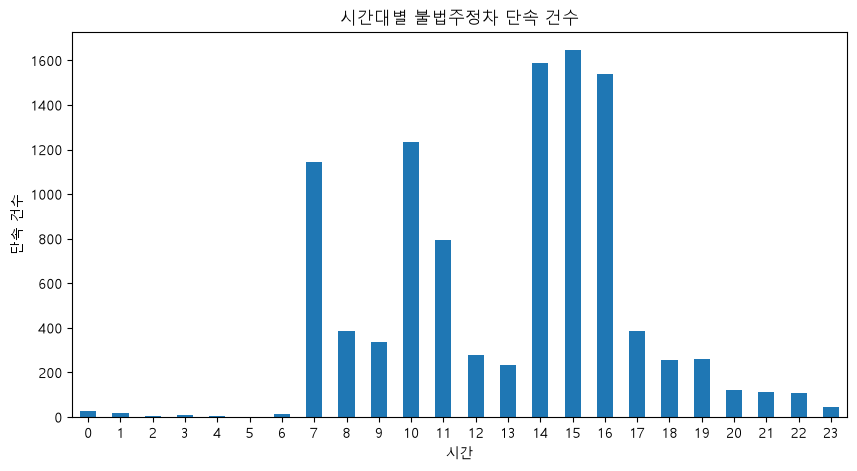

In [20]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(10, 5))

시간별.plot(kind="bar")

plt.title("시간대별 불법주정차 단속 건수")
plt.xlabel("시간")
plt.ylabel("단속 건수")
plt.xticks(rotation=0)

plt.show()